In [12]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 3
N = 256
#L = 1.
#L = N
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L

In [13]:

def kernel(bins, D, _db, _dx):
    if D == 1:
        return 2.
    if D == 2:
        return (2. * np.pi * bins * _db + np.pi * _db**2) / _dx**2
    if D == 3:
        return (4./3.) * np.pi * (3. * bins * _db**2 + 3. * bins**2 * _db + _db**3) / _dx**3


In [14]:
from scipy.stats import binned_statistic

def get_bins(min_bin, max_bin, nbins, max_half_bin_width=None, log_space=False):
    if log_space:
        bin_range = np.exp(np.linspace(np.log(min_bin), np.log(max_bin), nbins+1))
    else:
        bin_range = np.linspace(min_bin, max_bin, nbins+1)

    ## NOTE: Inherited code converts to integers; there are probably problems
    ##        with doing this... and also not doing this...
    ## valid_bins = np.unique(bin_range.astype(int))
    valid_bins = np.unique(bin_range.round(decimals=4))

    lower_bins, upper_bins = valid_bins[:-1], valid_bins[1:]

    bin_width = (upper_bins - lower_bins) / 2.
    if max_half_bin_width is not None:
        bin_width = np.minimum(bin_width, max_half_bin_width)

    bins = upper_bins - bin_width
    # consequences of not using the above note
    bin_edges = np.unique(np.concatenate((bins-bin_width, bins+bin_width)).round(decimals=4))
    return bins, bin_width, bin_edges

def bin_data(nar, ar, mean_func=np.nansum, std_func=np.nanstd,
             cut_excess=False, nan_small=False, min_bin=None,
             max_bin=None, bin_center=True, norm_bin_size=False, log_space=False,
             num_bins=None, ignore_nan=False, max_half_bin_width=None):
    # Find the basis of the position array
    pos = np.where(nar == 0)
    basis_index = [pos[i][0] for i in range(len(pos))]
    basis_index[0] = Ellipsis
    narbasis = nar[tuple(basis_index)]
    nn = narbasis[pos[0][0]:]

    # Calculate the bin space
    # Assume that the array is evenly space (this is an assumption made with everything)
    if min_bin is None:
        # If no minimum bin specified, then automatically choose one
        min_bin = np.nanmin(nn)

    if max_bin is None:
        max_bin = np.nanmax(nar)
    if isinstance(max_bin, str) and max_bin == 'basis':
        max_bin = np.nanmax(narbasis)

    if num_bins is None:
        binsize = np.diff(nn)[0]
        nbins = int(np.round(max_bin/binsize) + 1)
    else:
        nbins = num_bins

    bins, bin_widths, be = get_bins(min_bin, max_bin, nbins, max_half_bin_width, log_space)

    # Set bad, the regions outside the binning domain because scipy includes them into the binnings
    car = ar.copy()
    car[nar < min_bin] = np.nan
    car[nar > max_bin] = np.nan

    # Compute the binnings
    ar1d, bin_edges, _ = binned_statistic(nar.ravel(), car.ravel(), bins=be, statistic=mean_func)
    std1d, _, _ = binned_statistic(nar.ravel(), car.ravel(), bins=be, statistic=std_func)

    if nan_small:
        # Compute the counts, so we can ignore bad statistics
        cts, _, _ = binned_statistic(nar.ravel(), car.ravel(), bins=be, statistic='count')
        mask = cts <= 1
        ar1d[mask] = np.nan
        std1d[mask] = np.nan

    if bin_center:
       # Set the bins to the mid point of the bin edges
       bins1d = (bin_edges[1:] + bin_edges[:-1])/2.
    else:
       # Set the bins to the start of the bin edges
       bins1d = bin_edges[:-1]

    if max_half_bin_width is not None:
        # We should remove the bad bin edges (for the bins we don't want)
        mask = np.isin(bins1d, bins)
        ar1d = ar1d[mask]
        std1d = std1d[mask]
        bins1d = bins1d[mask]

    # Divide the functions by their bin sizes
    # NOTE: The bin widths are actually half the bin widths
    if max_half_bin_width:
        # We have already calculate this
        width = 2.*bin_widths
    else:
        # Otherwise, calculate from binned_statistic bin_edges
        lower_bins, upper_bins = bin_edges[:-1], bin_edges[1:]
        width = (upper_bins - lower_bins)
        if max_half_bin_width is not None:
            width = np.minimum(width, 2.*max_half_bin_width)
    
    if norm_bin_size:
        ar1d = ar1d / width
        std1d = std1d / width

    if cut_excess:
        # Cut off lags above the basis directions
        ar1d = ar1d[bins1d <= nn[-1]]
        std1d = std1d[bins1d <= nn[-1]]
        width = width[bins1d <= nn[-1]]
        bins1d = bins1d[bins1d <= nn[-1]]

    if ignore_nan:
        # Remove nan values
        mask = np.isfinite(ar1d)
        ar1d = ar1d[mask]
        std1d = std1d[mask]
        bins1d = bins1d[mask]
        width = width[mask]

    return bins1d, ar1d, width


In [15]:

fields = {}
vals = {}

for D in [1, 2, 3]:
    for N in [64, 128, 256]:
        grid_dims = [N for _ in range(D)]
        for L in [1., N, 2.*np.pi, 4.*np.pi]:
            phys_dims = [L for _ in range(D)]
            dk = twopi/L
            dx = L/N

            # WE ARE JUST TESTING THE INTEGRATION METHOD
            xvec = statfunc_base.get_lagvec_magnitude_array(grid_dims) * dx
            f = np.ones(grid_dims)

            _, fsum, db = bin_data(
                xvec, f, mean_func=np.nansum,
                cut_excess=True, nan_small=True,
                min_bin=0., max_bin=L/2,
                bin_center=False, log_space=False,# num_bins=N//2,
                ignore_nan=True, norm_bin_size=False)

            xmag, favg, db = bin_data(
                xvec, f, mean_func=np.nanmean,
                cut_excess=True, nan_small=True,
                min_bin=0., max_bin=L/2,
                bin_center=False, log_space=False,# num_bins=N//2,
                ignore_nan=True, norm_bin_size=False)

            vals[(D, N, L)] = (xmag, fsum, favg, db)


/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degre

(1, 64, 1.0) 1.0 1.0
(1, 64, 64) 1.0 1.0
(1, 64, 6.283185307179586) 1.0 1.0
(1, 64, 12.566370614359172) 1.0 1.0
(1, 128, 1.0) 1.0 1.0
(1, 128, 128) 1.0 1.0
(1, 128, 6.283185307179586) 1.0 1.0
(1, 128, 12.566370614359172) 1.0 1.0
(1, 256, 1.0) 1.0 1.0
(1, 256, 256) 1.0 1.0
(1, 256, 6.283185307179586) 1.0 1.0
(1, 256, 12.566370614359172) 1.0 1.0
(2, 64, 1.0) 0.9973482947398262 1.0
(2, 64, 64) 0.9973391921893227 1.0
(2, 64, 6.283185307179586) 0.9973350022778459 1.0
(2, 64, 12.566370614359172) 0.9973350022778459 1.0
(2, 128, 1.0) 0.9982299857049735 1.0
(2, 128, 128) 0.9982813791047629 1.0
(2, 128, 6.283185307179586) 0.9982432843900699 1.0
(2, 128, 12.566370614359172) 0.9982840722437176 1.0
(2, 256, 1.0) 0.997978537976395 1.0
(2, 256, 256) 0.9979703671357641 1.0
(2, 256, 6.283185307179586) 0.9979994693161391 1.0
(2, 256, 12.566370614359172) 0.9979703180838674 1.0
(3, 64, 1.0) 0.9976404793478522 1.0
(3, 64, 64) 0.9975886498887133 1.0
(3, 64, 6.283185307179586) 0.9975830851612557 1.0
(3, 64, 

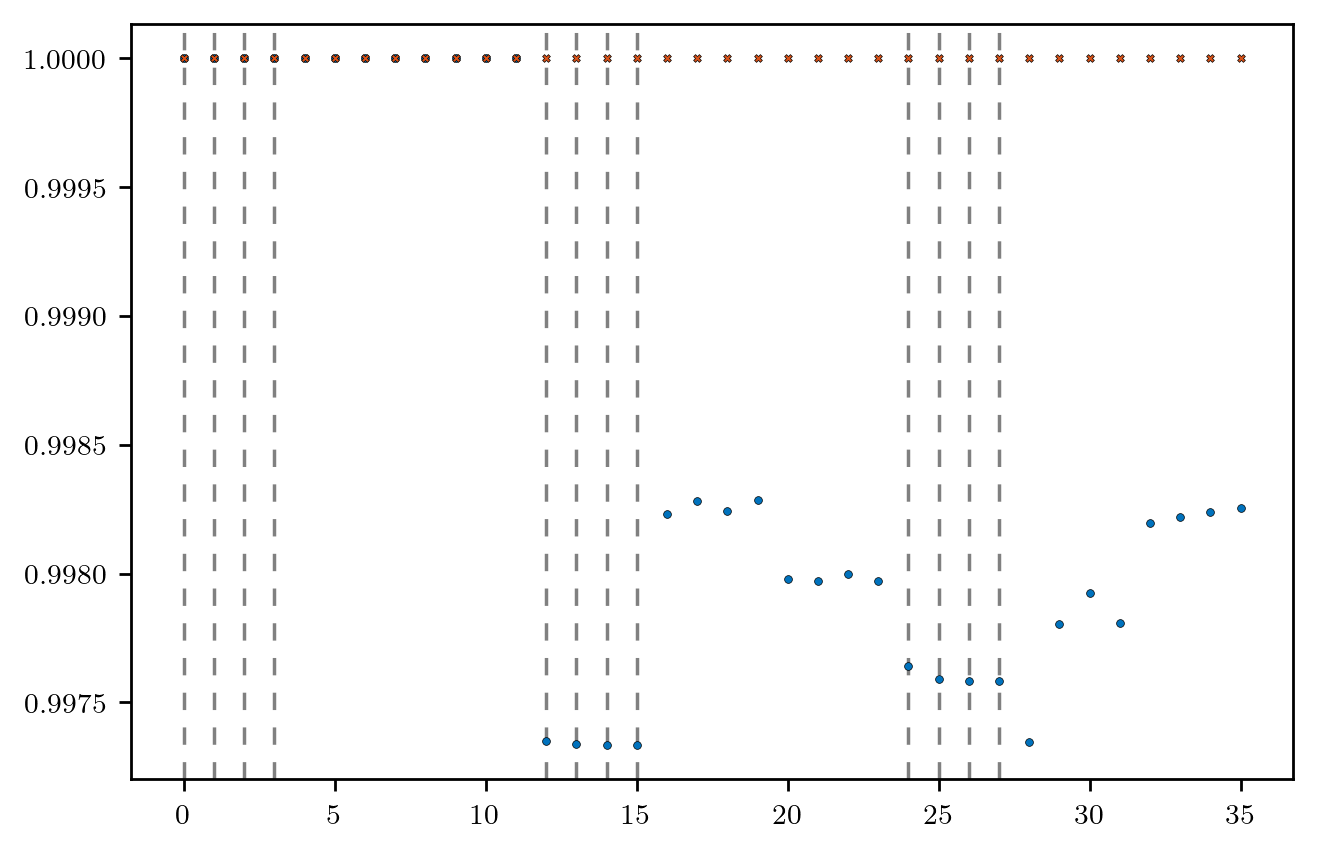

In [16]:
c = plotting.COLOR_CYCLE_6
p = 0

for k in vals.keys():
    D, N, L = k
    grid_dims = [N for _ in range(D)]
    phys_dims = [L for _ in range(D)]
    dk = twopi/L
    dx = L/N

    xmag, fsum, favg, db = vals[k]
    kern = kernel(xmag, D, db, dx)

    print(k, np.mean(fsum/kern), np.mean(favg))
    plt.scatter(p, np.mean(fsum/kern), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(p, np.mean(favg), marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
    if N == 64:
        plt.axvline(p, linewidth=1., linestyle=(0,(5,5)), color='gray', zorder=0)
    p = p + 1
    #assert np.allclose(fsum / kern, 1.), k
    #assert np.isclose(fsum / (kern * favg))


In [17]:
# k = 2, 256, 2.*np.pi
# D, N, L = k
# grid_dims = [N for _ in range(D)]
# phys_dims = [L for _ in range(D)]
# dk = twopi/L
# dx = L/N

# xmag, fsum, favg = vals[k]
# kern = kernel(xmag, D)

# plt.plot(xmag, fsum, label='$f_\Sigma(x)$')
# plt.plot(xmag, favg, label='$\\bar{f}(x)$')
# plt.plot(xmag, kern, label='$K(x)$')
# #plt.plot(xmag, fsum / fsum2, label='$\\bar{f}_\Sigma(x)$')

# plt.plot(xmag, favg * kern, linestyle=(0,(5,5)), label=r'$\bar{f}(x)K(x)$')
# plt.plot(xmag, fsum / kern, linestyle=(0,(5,5)), label=r'$f_\Sigma(x)/K(x)$')

# plt.legend()

In [18]:

# D, N, L = 3, 256, 2.*np.pi

# grid_dims = [N for _ in range(D)]
# phys_dims = [L for _ in range(D)]
# dk = twopi/L
# dx = L/N

# xvec = statfunc_base.get_lagvec_magnitude_array(grid_dims) * dx

# if xvec.ndim == 2:
#     X, Y = np.linspace(-N//2, N//2, N), np.linspace(-N//2, N//2, N)
#     plt.imshow(xvec/dx, extent=[-N//2, N//2, -N//2, N//2])
#     plt.colorbar()
#     plt.contour(X, Y, xvec/dx, colors='black')
#     plt.colorbar()

# nar = xvec
# min_bin = 0
# max_bin = L/2
# num_bins = None#N//2
# pos = np.where(nar == 0)
# basis_index = [pos[i][0] for i in range(len(pos))]
# basis_index[0] = Ellipsis
# narbasis = nar[tuple(basis_index)]
# nn = narbasis[pos[0][0]:]
# # Calculate the bin space
# # Assume that the array is evenly space (this is an assumption made with everything)
# if min_bin is None:
#     # If no minimum bin specified, then automatically choose one
#     min_bin = np.nanmin(nn)
# if max_bin is None:
#     max_bin = np.nanmax(nar)
# if isinstance(max_bin, str) and max_bin == 'basis':
#     max_bin = np.nanmax(narbasis)
# if num_bins is None:
#     binsize = np.diff(nn)[0]
#     nbins = int(np.round(max_bin/binsize) + 1)
# else:
#     nbins = num_bins
# bins, bin_widths, be = get_bins(min_bin, max_bin, nbins, None, False)

# IDX = 70

# region = np.ones_like(xvec, dtype=int)
# region[xvec <= be[IDX]] = 0
# region[xvec >= be[IDX+1]] = 0
# print(be[IDX], be[IDX+1], np.nansum(region), 2.*bin_widths[IDX] / dx)

# if xvec.ndim == 2:
#     plt.contour(X, Y, region, colors='blue', linewidth=1.)
#     plt.scatter(0, 0, marker='+', color='red', s=10.)
#     plt.axvline(0, color='red', linewidth=1.)
#     plt.axhline(0, color='red', linewidth=1.)

In [19]:
# A = []
# for i in range(len(be)-1):
#     region = np.ones_like(xvec, dtype=int)
#     region[xvec <= be[i]] = 0
#     region[xvec > be[i+1]] = 0
#     A.append(np.nansum(region))

# A = np.array(A)
# db = 2.*bin_widths

# if xvec.ndim == 2:
#     _n = np.arange(0, len(be) - 1)
#     plt.scatter(_n, A, marker='o', s=10.)
#     plt.scatter(_n, (2.*np.pi*(_n*db)*db + np.pi*db**2) / dx**2, marker='x', s=10.)# - np.array(A))
#     plt.scatter(vals[(D,N,L)][0]/dx, vals[(D,N,L)][1], marker='v', s=10.)
# if xvec.ndim == 3:
#     _n = np.arange(0, len(be) - 1)
#     plt.scatter(_n, A, marker='o', s=10.)
#     plt.scatter(_n, (4./3.)*np.pi*(db**3 + 3.*(_n*db)*db**2 + 3.*(_n*db)**2*db) / dx**3, marker='x')# - np.array(A))
#     plt.scatter(vals[(D,N,L)][0]/dx, vals[(D,N,L)][1], marker='v', s=10.)
# # if xvec.ndim == 2:
# #     plt.plot(vals[(D,N,L)][0], vals[(D,N,L)][1])
# #     plt.plot(bins, 2.*np.pi*bins)
# #     plt.plot(bins, np.array(A), linestyle=(0,(5,5)))

In [20]:
# from scipy.integrate import tplquad

# def diff_volume(p,t,r):
#     return r**2 * np.sin(p)

# vol = []
# for i in range(len(be) - 1):
#     vol.append(tplquad(diff_volume, be[IDX], be[IDX+1], lambda r: 0., lambda r: 2.*np.pi, lambda r,t: 0., lambda r,t: np.pi)[0])
# vol = np.array(vol)
